In [1]:
#importing import libraries
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, BatchNormalization, Dropout

In [2]:
#generator for training dataset
train_data_set=keras.utils.image_dataset_from_directory(
directory='../.resource/data/train',
labels='inferred',
label_mode='int',
batch_size=32,
image_size=(256,256)
)

#generator for validating dataset
validation_data_set=keras.utils.image_dataset_from_directory(
directory='../.resource/data/validation',
labels='inferred',
label_mode='int',
batch_size=32,
image_size=(256,256)
)

Found 3360 files belonging to 2 classes.
Found 840 files belonging to 2 classes.


In [3]:
#Normalization
def process(image,label):
    image = tf.cast(image/255., tf.float32)
    return image,label

train_data_set = train_data_set.map(process)
validation_data_set = validation_data_set.map(process)

In [4]:
#Create CNN Model with 3layers-32,64,128
model = Sequential()

model.add(Conv2D(32,kernel_size=(3,3), padding='valid', activation='relu', input_shape=(256,256,3)))
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

model.add(Conv2D(64,kernel_size=(3,3), padding='valid', activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

model.add(Conv2D(128,kernel_size=(3,3), padding='valid', activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

model.add(Flatten())

model.add(Dense(128,activation='relu'))

model.add(Dense(64,activation='relu'))

model.add(Dense(1,activation='sigmoid'))

/home/raviteja/Desktop/Python/TBDetection/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
W0000 00:00:1784525532.677636    4669 cpu_allocator_impl.cc:82] Allocation of 58982400 exceeds 10% of free system memory.
W0000 00:00:1784525532.705511    4669 cpu_allocator_impl.cc:82] Allocation of 58982400 exceeds 10% of free system memory.
W0000 00:00:1784525532.712627    4669 cpu_allocator_impl.cc:82] Allocation of 58982400 exceeds 10% of free system memory.


In [5]:
#compile model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [6]:
#train the model
history = model.fit(train_data_set, epochs=10, validation_data=validation_data_set)

Epoch 1/10


W0000 00:00:1784525532.984535    4669 cpu_allocator_impl.cc:82] Allocation of 58982400 exceeds 10% of free system memory.
W0000 00:00:1784525533.239789    6070 cpu_allocator_impl.cc:82] Allocation of 264257536 exceeds 10% of free system memory.


105/105 ━━━━━━━━━━━━━━━━━━━━ 154s 1s/step - accuracy: 0.8795 - loss: 0.2795 - val_accuracy: 0.8798 - val_loss: 0.2882
Epoch 2/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 157s 1s/step - accuracy: 0.9610 - loss: 0.1080 - val_accuracy: 0.9345 - val_loss: 0.1560
Epoch 3/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 145s 1s/step - accuracy: 0.9738 - loss: 0.0733 - val_accuracy: 0.9643 - val_loss: 0.1216
Epoch 4/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 135s 1s/step - accuracy: 0.9756 - loss: 0.0689 - val_accuracy: 0.9643 - val_loss: 0.1254
Epoch 5/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 141s 1s/step - accuracy: 0.9720 - loss: 0.0711 - val_accuracy: 0.9488 - val_loss: 0.2005
Epoch 6/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 132s 1s/step - accuracy: 0.9685 - loss: 0.0813 - val_accuracy: 0.9500 - val_loss: 0.2224
Epoch 7/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 143s 1s/step - accuracy: 0.9845 - loss: 0.0433 - val_accuracy: 0.9655 - val_loss: 0.1997
Epoch 8/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 141s 1s/step - accuracy: 0.9899 - loss: 0.0308 - val_accuracy: 0.965

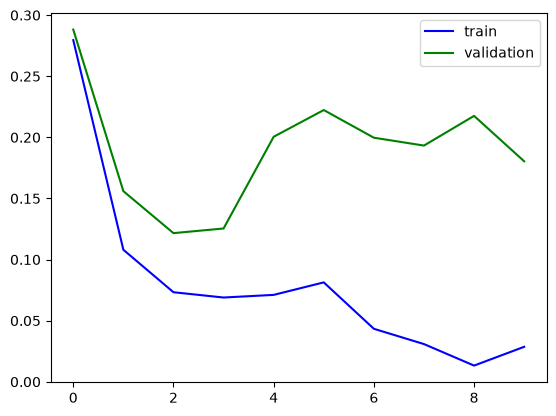

In [7]:
#loss train v/s validation
import matplotlib.pyplot as plt
plt.plot(history.history['loss'], color='blue', label='train')
plt.plot(history.history['val_loss'], color='green', label='validation')
plt.legend()
plt.show()

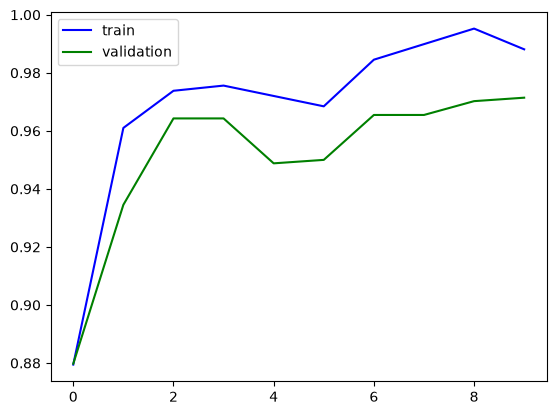

In [8]:
#accuracy train v/s validation
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'], color='blue', label='train')
plt.plot(history.history['val_accuracy'], color='green', label='validation')
plt.legend()
plt.show()

In [9]:
loss = history.history['loss']
loss = min(loss)
print("---------------------------------")
print("PERFORMANCE ANALYSIS")
print("---------------------------------")
print()
acc_cnn=100-loss
print("1.Accuracy    =",acc_cnn, '%')
print()
print("2.Error Rate  =",loss )

---------------------------------
PERFORMANCE ANALYSIS
---------------------------------

1.Accuracy    = 99.98676328640431 %

2.Error Rate  = 0.013236713595688343


In [10]:
#model summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,541,893 (169.91 MB)

 Trainable params: 14,847,297 (56.64 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 29,694,596 (113.28 MB)

In [11]:
#saving model
model.save('../.resource/tuberculosis.h5')

In [12]:
#loading the saved model
from tensorflow.keras.models import load_model
model = load_model('../.resource/tuberculosis.h5')